In [1]:
import matplotlib.pyplot as plt
import numpy as np

import time

import sys
import os

from datetime import datetime
import subprocess

from os.path import exists



import matplotlib as mpl

import pickle

In [2]:

fileset = 2


if fileset == 1 :

    input_dir1 = 'bootstrap-all-in-one-inspect-of-1d-5a'
    input_dir2 = 'bootstrap-all-in-one-inspect-of-1d-6a'

    name1 = 'relu'
    name2 = 'gelu'


if fileset == 2 :
    
    
    input_dir1 = 'bootstrap-ensemble-1d-1b'
    input_dir2 = 'bootstrap-ensemble-1d-1c'

    name1 = 'relu'
    name2 = 'gelu, beta=4'




In [3]:
with open( '%s/simple-calc-per-sample-results.npy' % input_dir1, 'rb') as f :
    mean_vals1 = np.load(f)
    cov_vals1 = np.load(f)
    
with open( '%s/simple-calc-per-sample-results.npy' % input_dir2, 'rb') as f :
    mean_vals2 = np.load(f)
    cov_vals2 = np.load(f)    

<function matplotlib.pyplot.show(close=None, block=None)>

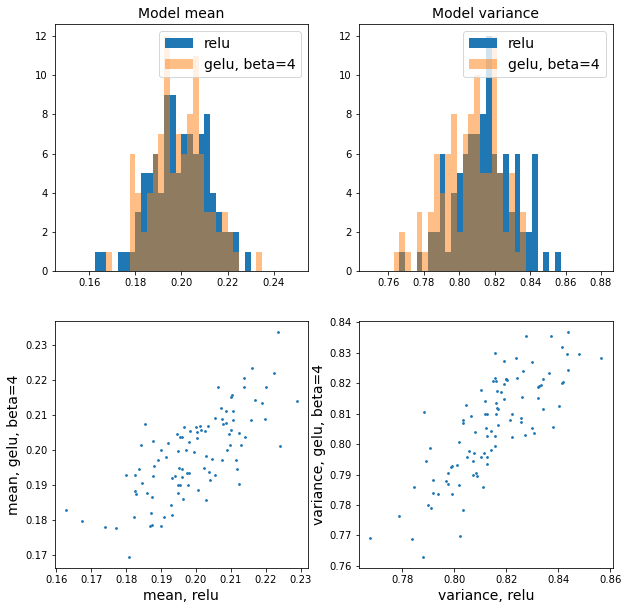

In [4]:
fig,ax = plt.subplots( 2, 2, figsize=(2*5,2*5))

mean_min = 0.15
mean_max = 0.25

cov_min = 0.75
cov_max = 0.88

hbins = 40

axi = ax[0,0]
axi.hist( mean_vals1[0,:], range=[mean_min, mean_max], bins=hbins, label=name1)
axi.hist( mean_vals2[0,:], range=[mean_min, mean_max], bins=hbins, label=name2, alpha=0.50)
axi.set_title( 'Model mean', fontsize=14 )
axi.legend( fontsize=14 )

axi = ax[0,1]
axi.hist( cov_vals1[0,0,:], range=[cov_min, cov_max], bins=hbins, label=name1)
axi.hist( cov_vals2[0,0,:], range=[cov_min, cov_max], bins=hbins, label=name2, alpha=0.50)
axi.set_title( 'Model variance', fontsize=14 )
axi.legend( fontsize=14 )

axi = ax[1,0]
axi.scatter( mean_vals1[0,:], mean_vals2[0,:], s=3.1)
axi.set_xlabel( 'mean, %s' % name1, fontsize=14 )
axi.set_ylabel( 'mean, %s' % name2, fontsize=14 )

axi = ax[1,1]
axi.scatter( cov_vals1[0,:], cov_vals2[0,:], s=3.1 )
axi.set_xlabel( 'variance, %s' % name1, fontsize=14 )
axi.set_ylabel( 'variance, %s' % name2, fontsize=14 )

plt.show

In [5]:
mean_vals1

array([[0.19734085, 0.19644539, 0.19725974, 0.2139576 , 0.20731605,
        0.18258124, 0.18235953, 0.19303653, 0.22881317, 0.19291705,
        0.17997815, 0.19602523, 0.18769249, 0.18438398, 0.20407829,
        0.20068238, 0.19793918, 0.20727835, 0.19472902, 0.18918203,
        0.18807031, 0.18370374, 0.19533922, 0.2201314 , 0.20351411,
        0.20537675, 0.18075172, 0.1674276 , 0.19602505, 0.21584708,
        0.20231173, 0.20543504, 0.19756599, 0.18292286, 0.2238957 ,
        0.18760414, 0.20895154, 0.19796003, 0.18690167, 0.20033983,
        0.20465216, 0.20287896, 0.19816562, 0.20009217, 0.21035419,
        0.21381357, 0.18750015, 0.19145059, 0.21044341, 0.21004403,
        0.21227069, 0.2127629 , 0.20853381, 0.18717278, 0.20036024,
        0.19194083, 0.19544612, 0.19469474, 0.20252853, 0.21685452,
        0.19931646, 0.18745069, 0.18599051, 0.21610891, 0.19458544,
        0.19596685, 0.21143955, 0.1899917 , 0.21177509, 0.1900966 ,
        0.223341  , 0.21363049, 0.20776238, 0.17

In [6]:
cov_vals1

array([[[0.80329402, 0.81634949, 0.83336134, 0.81608269, 0.79741318,
         0.77847909, 0.78364026, 0.81203123, 0.82206601, 0.82580604,
         0.81626204, 0.82554829, 0.81587875, 0.85638478, 0.82376339,
         0.82150472, 0.81891367, 0.83714338, 0.80343914, 0.83065929,
         0.80768175, 0.81262827, 0.82421132, 0.80426358, 0.8139327 ,
         0.81039468, 0.82699067, 0.82038063, 0.82980761, 0.79155535,
         0.8080427 , 0.80181753, 0.84133093, 0.76769181, 0.84157872,
         0.83235724, 0.80105073, 0.81468323, 0.82219344, 0.79918297,
         0.80809358, 0.8125956 , 0.805678  , 0.78779822, 0.79901219,
         0.81269421, 0.81256604, 0.83220318, 0.79871958, 0.81559118,
         0.80731243, 0.81547421, 0.81969254, 0.81142869, 0.84782594,
         0.81578298, 0.78990924, 0.84030189, 0.84381009, 0.82739886,
         0.78810109, 0.79735207, 0.81411   , 0.8086976 , 0.81158672,
         0.79668099, 0.81676827, 0.80327625, 0.80161202, 0.81591668,
         0.79380508, 0.81904005, 0